# Maken generieren

## Brain mask

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

nii = nib.load("Segmentations/mask_lr.nii")  # oder .nii.gz
brain_mask = nii.get_fdata()         # -> numpy array (float64)

# Lesion mask (big)

In [2]:
import nibabel as nib
import numpy as np

# NIfTI laden
nii = nib.load("Segmentations/Lesion_Double_lr.nii")
Lesion_mask = nii.get_fdata()

# Define helper Function for RMSE over time

In [3]:
import os
import numpy as np

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.flip(np.swapaxes(np.load(path), 0, -2), axis=1)

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

def relative_rmse(gt, pred, mask, eps=1e-12):
    """
    gt, pred: arrays with shape (x,y,z)
    mask: weight map (can be binary or float in [0,1])
    returns: weighted relative RMSE
    """

    gt = np.asarray(gt)
    pred = np.asarray(pred)
    w = np.asarray(mask)

    # gültige Voxels: w>0 und finite Werte
    m = (w > 0) & np.isfinite(w) & np.isfinite(gt) & np.isfinite(pred)

    if not np.any(m):
        return np.nan

    ww = w[m].astype(np.float64)
    diff2 = (gt[m] - pred[m])**2

    # gewichtetes MSE
    weighted_mse = np.sum(ww * diff2) / (np.sum(ww) + eps)

    # Normalisierung über Range in Ωm
    denom = (np.max(gt[m]) - np.min(gt[m])) + eps

    return np.sqrt(weighted_mse) / denom

def relative_rmse_time(gt, pred, mask, eps=1e-12):
    """
    Returns relative RMSE as a function of time (last index)
    """
    T = gt.shape[-1]
    RMSE = []

    for i in range(0,T):
        RMSE.append(relative_rmse(gt[..., i], pred[..., i], mask, eps))

    return RMSE

def relative_rmse_time_stats(gt, preds, mask, eps=1e-12):
    """
    preds: list of predictions with same shape as gt

    returns:
        mean_rmse_time, std_rmse_time
    """
    rmses = np.stack([relative_rmse_time(gt, p, mask, eps) for p in preds], axis=0)
    return rmses.mean(axis=0), rmses.std(axis=0)

# ---------- helper ----------
def compute_mean_std_rrmse_time(root, metab, mask, gt_method, rep_methods, suffix="Orig", eps=1e-12):
    """
    rep_methods: dict label -> list of method-folders (reps)
    returns: dict label -> (mean(T,), std(T,))
    """
    gt = load_metab_map(root, gt_method, metab, suffix)

    out = {}
    for label, reps in rep_methods.items():
        preds = load_multiple_metab_maps(root, reps, metab, suffix)
        mean_t, std_t = relative_rmse_time_stats(gt, preds, mask, eps)
        out[label] = (np.asarray(mean_t), np.asarray(std_t))
    return out

Metabo = "Lac" 
MASK = Lesion_mask # brain_mask

Noisy_Reps = ["Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy"]
Deep_Reps = ["Lesion_Double_deep_tMPPCA_5D", "Lesion_Double_tMPPCA_5D", "Lesion_Double_deep_tMPPCA_5D"]
tMPPCA_Reps = ["Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D"]

GT_Lac = load_metab_map("MetabMaps", "Lesion_Double_GT", f"{Metabo}")



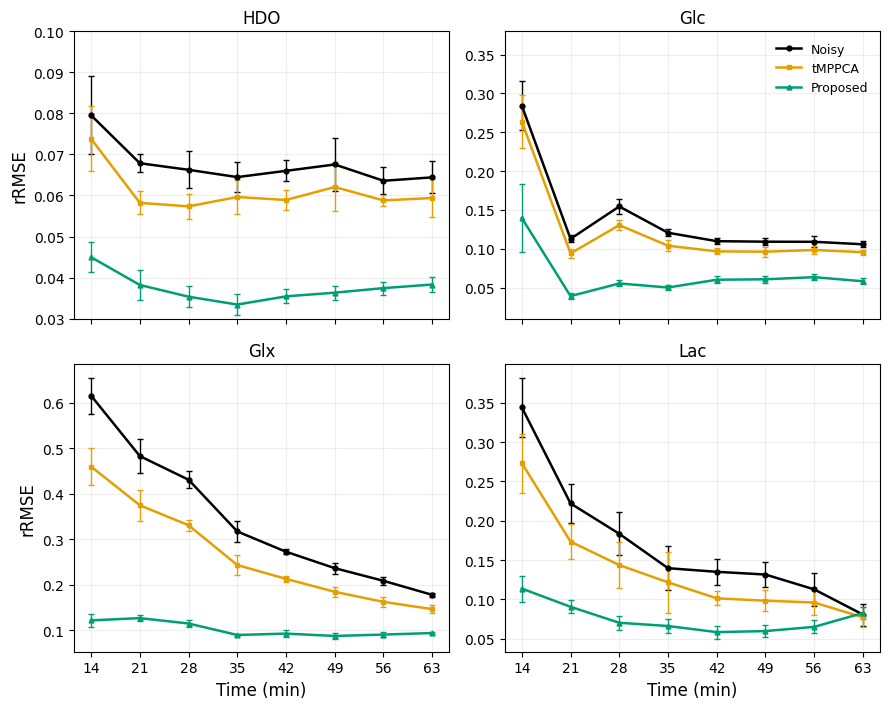

In [4]:
# ---------- USER SETTINGS ----------
root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

Metabo = "Lac"
MASK = Lesion_mask  # oder brain_mask

Noisy_Reps  = [
    "Lesion_double_noisy_1", "Lesion_double_noisy_2", "Lesion_double_noisy_3",
    "Lesion_double_noisy_4", "Lesion_double_noisy_5", "Lesion_double_noisy_6"
]
Deep_Reps   = [
    "Lesion_double_deep_tmppca_1", "Lesion_double_deep_tmppca_2",
    "Lesion_double_deep_tmppca_3", "Lesion_double_deep_tmppca_4",
    "Lesion_double_deep_tmppca_5", "Lesion_double_deep_tmppca_6"
]
tMPPCA_Reps = [
    "Lesion_double_tmppca_1", "Lesion_double_tmppca_2", "Lesion_double_tmppca_3",
    "Lesion_double_tmppca_4", "Lesion_double_tmppca_5", "Lesion_double_tmppca_6"
]

# --- ONLY 3 METHODS ---
rep_methods = {
    "Noisy":     Noisy_Reps,
    "tMPPCA":    tMPPCA_Reps,
    "Proposed":  Deep_Reps,
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

DISPLAY_METHOD = {
    "Noisy":    "Noisy",
    "tMPPCA":   "tMPPCA",
    "Proposed": "Proposed",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])


# ===================== PLOTTING =====================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DEFAULT_COLORS = {
    "noisy": "#000000",
    "tMPPCA_5D": "#E69F00",
    "deep_tMPPCA_5D": "#009E73",
}

DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
}

LABEL_TO_SUFFIX = {
    "Noisy": "noisy",
    "tMPPCA": "tMPPCA_5D",
    "Proposed": "deep_tMPPCA_5D",
}

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.2), sharex=True)
axes = axes.ravel()

lw_main, ms_main, cap, elw = 1.8, 3.5, 2, 1.0

legend_labels = list(rep_methods.keys())

# Legend handles (3 methods)
legend_handles = []
for k in legend_labels:
    suf = LABEL_TO_SUFFIX[k]
    legend_handles.append(
        Line2D(
            [0], [0],
            color=DEFAULT_COLORS[suf],
            linestyle="-",
            lw=lw_main,
            marker=DEFAULT_MARKERS[suf],
            ms=ms_main,
            label=DISPLAY_METHOD[k]
        )
    )

for ax, (metab, mask) in zip(axes, metabs):
    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    x = np.asarray(time_axis)

    # plot the 3 methods
    for lab in legend_labels:
        mean_t, std_t = curves[lab]
        mean_t = np.asarray(mean_t)
        suf = LABEL_TO_SUFFIX[lab]
        col = DEFAULT_COLORS[suf]
        mk  = DEFAULT_MARKERS[suf]

        ax.errorbar(
            x, mean_t,
            yerr=std_t,
            color=col,
            linestyle="-",
            marker=mk,
            lw=lw_main,
            ms=ms_main,
            capsize=cap,
            elinewidth=elw,
            zorder=3,
        )

    ax.set_title(DISPLAY_NAME.get(metab, metab))
    ax.grid(True, alpha=0.2)
    ax.set_xticks(x)

    # keep readable y-scales (as before)
    if metab == "water":
        ax.set_ylim(0.03, 0.1)
    elif metab == "Glc":
        ax.set_ylim(0.01, 0.38)

    if ax in (axes[0], axes[2]):
        ax.set_ylabel("rRMSE")
    else:
        ax.set_ylabel("")

axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

fig.tight_layout()
plt.savefig("rrmse_timecourse_2x2.pdf", bbox_inches="tight")
plt.show()